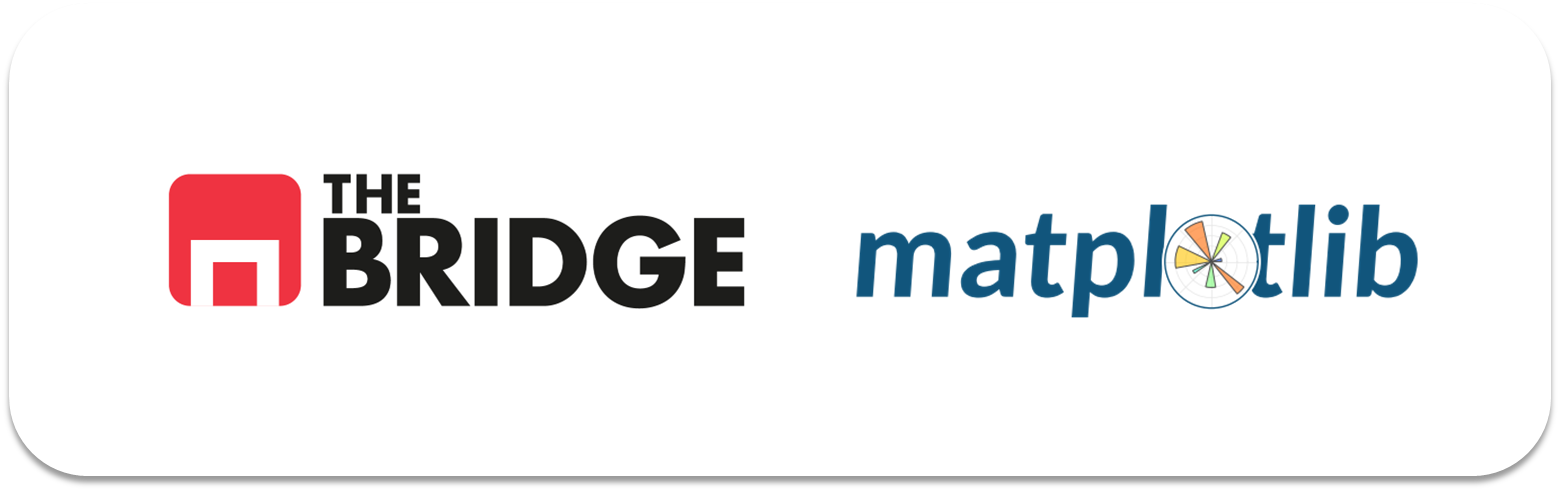

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [6]:
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [7]:
df = pd.read_csv("./data/california_cities.csv", index_col=0)

display(df.head(10))
df.info()
df.describe()
display(df.isna().sum().sort_values(ascending=False))

antes = len(df)
df = df.dropna()
print(f"Filas: {antes} -> {len(df)} tras dropna")


,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57
7,AmadorCity,38.419444,-120.824167,280.0,919.0,185,0.314,0.314,0.000,0.813,0.813,0.000,0.00
8,AmericanCanyon,38.168056,-122.252500,14.0,46.0,19454,4.845,4.837,0.008,12.548,12.527,0.021,0.17
9,Anaheim,33.836111,-117.889722,48.0,157.0,336000,50.811,49.835,0.976,131.600,129.073,2.527,1.92


<class 'pandas.core.frame.DataFrame'>
Index: 482 entries, 0 to 481
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                482 non-null    object 
 1   latd                482 non-null    float64
 2   longd               482 non-null    float64
 3   elevation_m         434 non-null    float64
 4   elevation_ft        470 non-null    float64
 5   population_total    482 non-null    int64  
 6   area_total_sq_mi    480 non-null    float64
 7   area_land_sq_mi     482 non-null    float64
 8   area_water_sq_mi    481 non-null    float64
 9   area_total_km2      477 non-null    float64
 10  area_land_km2       478 non-null    float64
 11  area_water_km2      478 non-null    float64
 12  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(1), object(1)
memory usage: 52.7+ KB


elevation_m           48
elevation_ft          12
area_water_percent     5
area_total_km2         5
area_water_km2         4
area_land_km2          4
area_total_sq_mi       2
area_water_sq_mi       1
city                   0
latd                   0
longd                  0
area_land_sq_mi        0
population_total       0
dtype: int64

Filas: 482 -> 427 tras dropna


#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

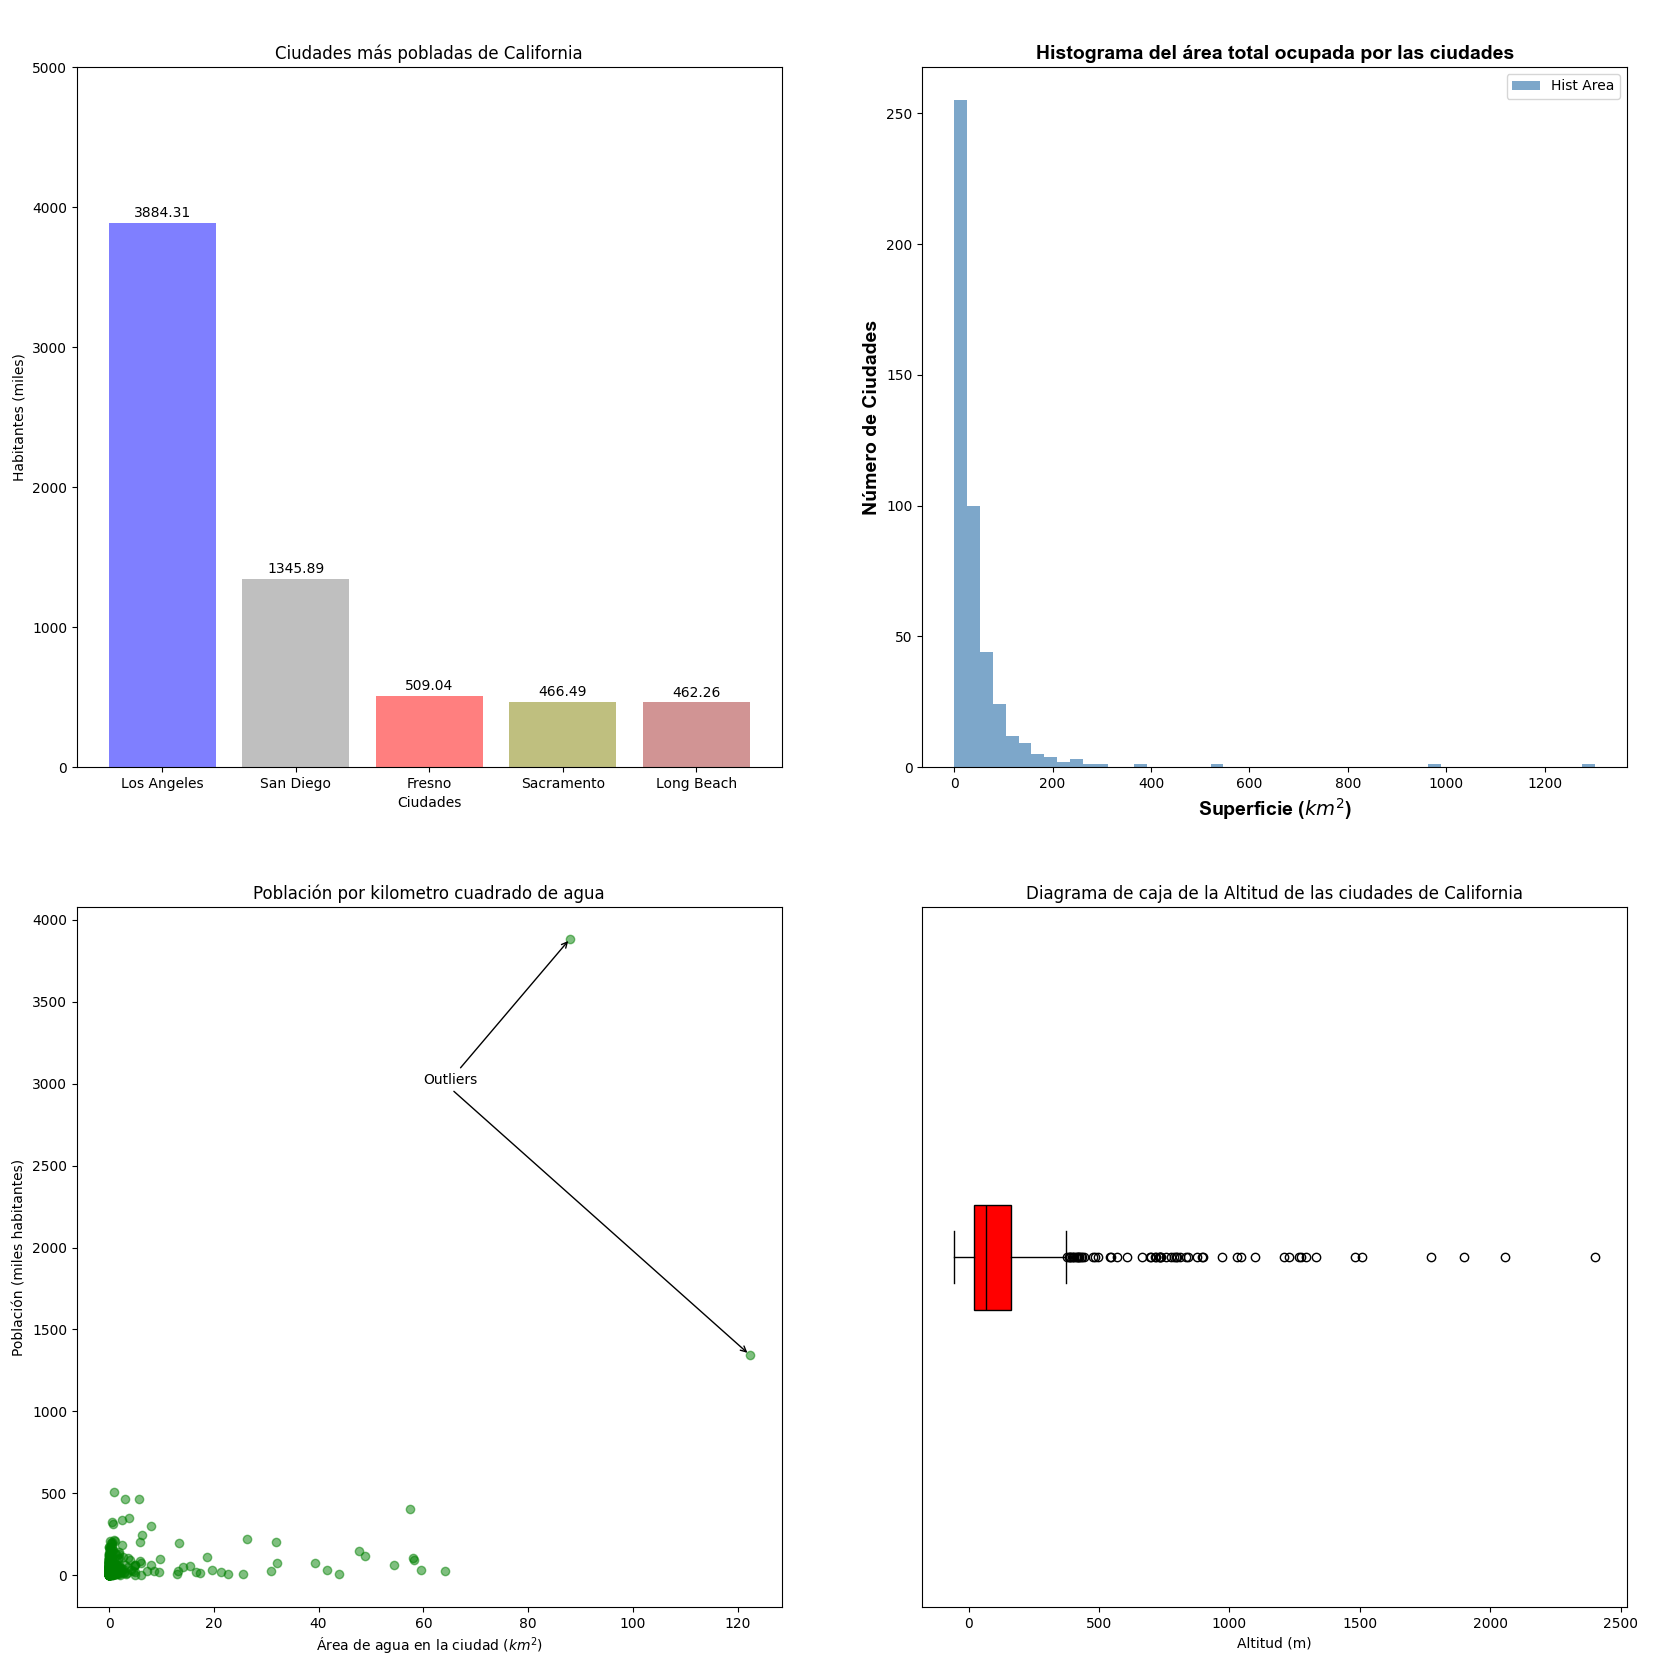

### Gráficos por separado

Un gráfico por celda; después el 2×2.


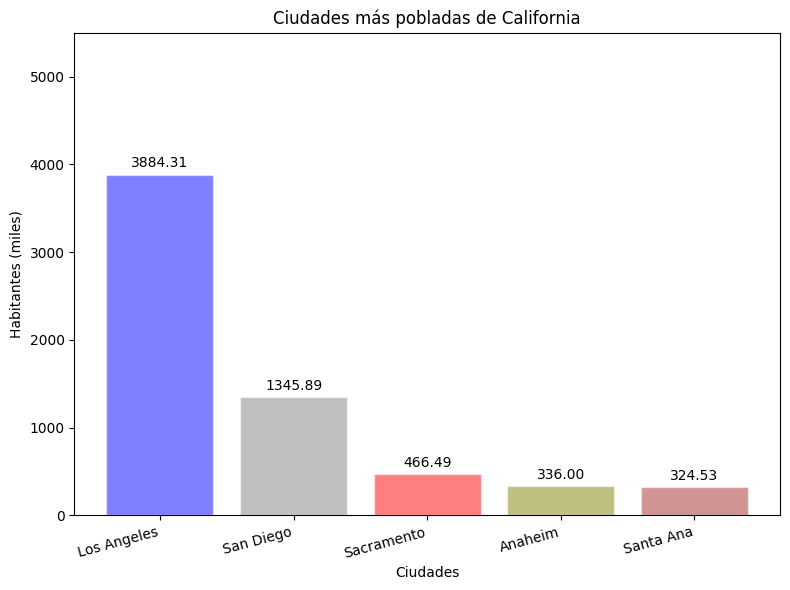

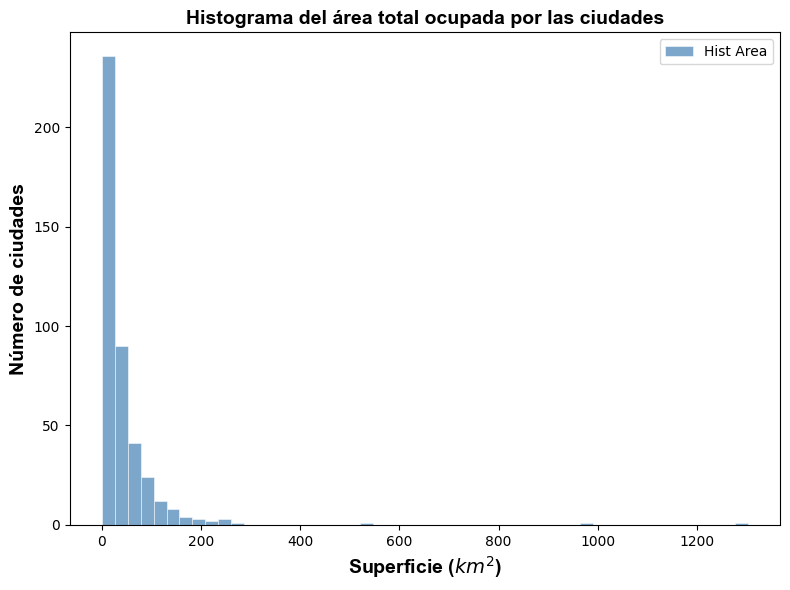

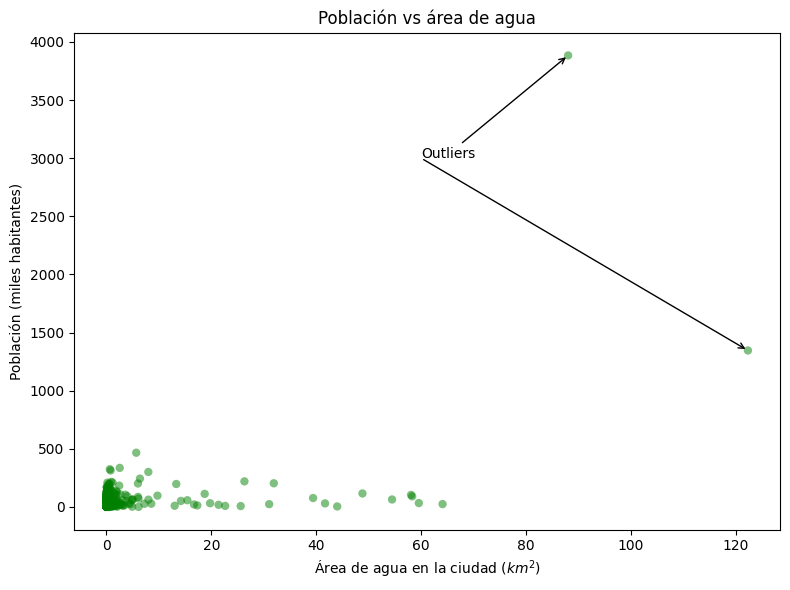

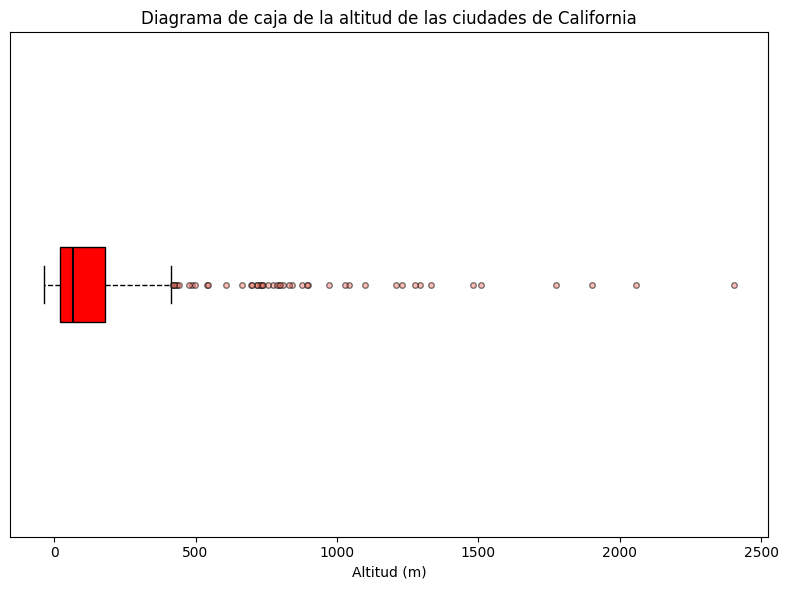

In [8]:
# los nombres en el csv vienen en CamelCase (ej. LosAngeles), los separo
def espaciar_nombre_ciudad(nombre):
    return re.sub(r"([a-z])([A-Z])", r"\1 \2", nombre)

fuente = dict(family="Arial", size=14, weight="bold")
top5 = df.nlargest(5, "population_total").set_index("city")
colores = ["blue", "gray", "red", "olive", "brown"]
ciudades_lab = [espaciar_nombre_ciudad(c) for c in top5.index]
pob_miles = top5["population_total"] / 1000
top2 = df.nlargest(2, "population_total")

# barras
plt.figure(figsize=(8, 6))
barras = plt.bar(ciudades_lab, pob_miles, color=colores, alpha=0.5, edgecolor="white")
plt.ylim(0, 5500)
plt.ylabel("Habitantes (miles)")
plt.xlabel("Ciudades")
plt.title("Ciudades más pobladas de California")
plt.xticks(rotation=15, ha="right")
plt.bar_label(barras, fmt="%.2f", padding=3)
plt.tight_layout()
plt.show()

# histograma
plt.figure(figsize=(8, 6))
plt.hist(df["area_total_km2"], bins=50, color="steelblue", alpha=0.7,
         edgecolor="white", linewidth=0.5, label="Hist Area")
plt.xlabel(r"Superficie ($km^2$)", fontdict=fuente)
plt.ylabel("Número de ciudades", fontdict=fuente)
plt.title("Histograma del área total ocupada por las ciudades", fontdict=fuente)
plt.legend()
plt.tight_layout()
plt.show()

# scatter
plt.figure(figsize=(8, 6))
plt.scatter(
    df["area_water_km2"],
    df["population_total"] / 1000,
    alpha=0.5,
    color="green",
    edgecolors="none",
)
plt.xlabel("Área de agua en la ciudad ($km^2$)")
plt.ylabel("Población (miles habitantes)")
plt.title("Población vs área de agua")

for i, (_, fila) in enumerate(top2.iterrows()):
    etiqueta = "Outliers" if i == 0 else ""
    plt.annotate(
        text=etiqueta,
        xy=(fila["area_water_km2"], fila["population_total"] / 1000),
        xytext=(60, 3000),
        arrowprops=dict(arrowstyle="->"),
    )
plt.tight_layout()
plt.show()

# boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(
    df["elevation_m"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="red"),
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="salmon", markersize=4, alpha=0.5),
    whiskerprops=dict(linestyle="--"),
)
plt.xlabel("Altitud (m)")
plt.title("Diagrama de caja de la altitud de las ciudades de California")
plt.yticks([])
plt.tight_layout()
plt.show()


### Panel 2×2

Los cuatro juntos para entregar y guardar.


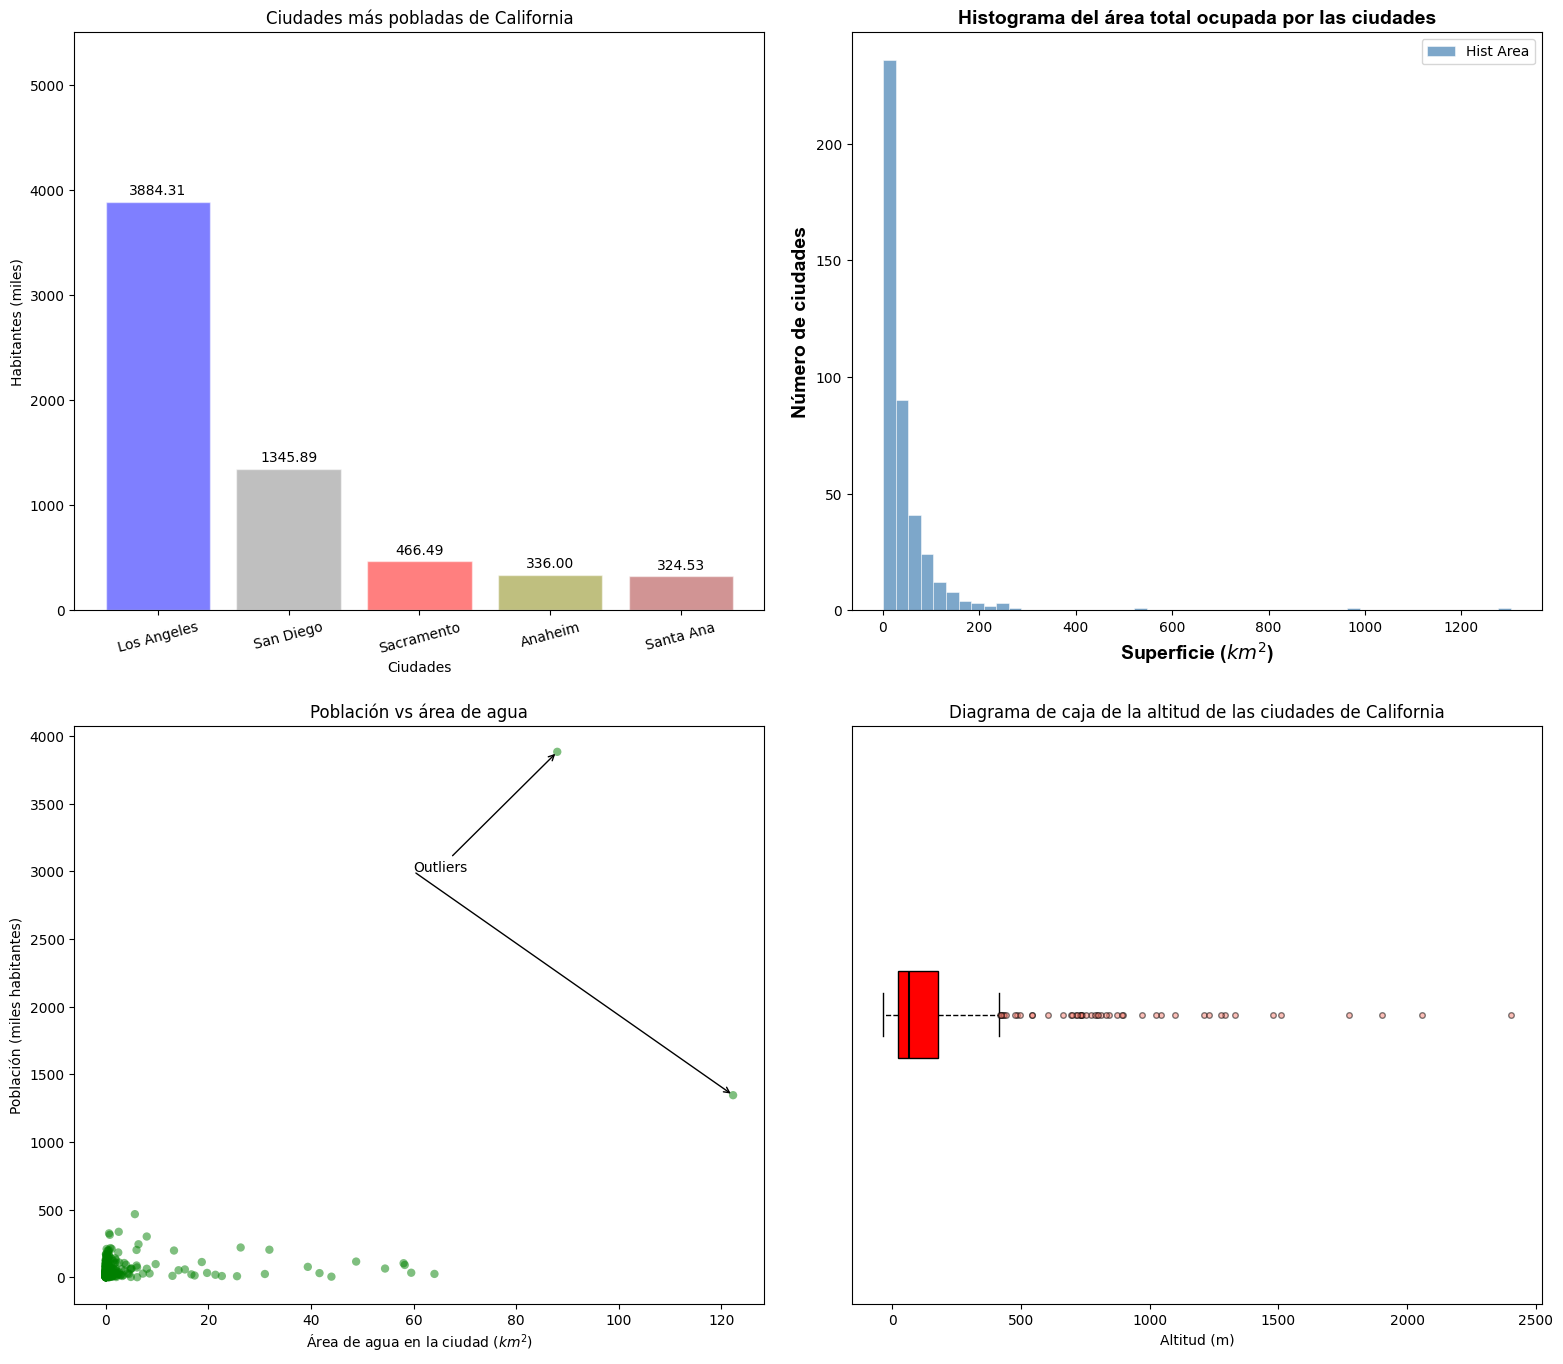

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ax1, ax2, ax3, ax4 = axes.ravel()

# Barras
b1 = ax1.bar(ciudades_lab, pob_miles, color=colores, alpha=0.5, edgecolor="white")
ax1.set_ylim(0, 5500)
ax1.set_ylabel("Habitantes (miles)")
ax1.set_xlabel("Ciudades")
ax1.set_title("Ciudades más pobladas de California")
ax1.tick_params(axis="x", rotation=15)
ax1.bar_label(b1, fmt="%.2f", padding=3)

# Histograma
ax2.hist(df["area_total_km2"], bins=50, color="steelblue", alpha=0.7,
         edgecolor="white", linewidth=0.5, label="Hist Area")
ax2.set_xlabel(r"Superficie ($km^2$)", fontdict=fuente)
ax2.set_ylabel("Número de ciudades", fontdict=fuente)
ax2.set_title("Histograma del área total ocupada por las ciudades", fontdict=fuente)
ax2.legend()

# Scatter
ax3.scatter(
    df["area_water_km2"],
    df["population_total"] / 1000,
    alpha=0.5,
    color="green",
    edgecolors="none",
)
ax3.set_xlabel("Área de agua en la ciudad ($km^2$)")
ax3.set_ylabel("Población (miles habitantes)")
ax3.set_title("Población vs área de agua")
for i, (_, fila) in enumerate(top2.iterrows()):
    etiqueta = "Outliers" if i == 0 else ""
    ax3.annotate(
        text=etiqueta,
        xy=(fila["area_water_km2"], fila["population_total"] / 1000),
        xytext=(60, 3000),
        arrowprops=dict(arrowstyle="->"),
    )

# Boxplot
ax4.boxplot(
    df["elevation_m"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="red"),
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="salmon", markersize=4, alpha=0.5),
    whiskerprops=dict(linestyle="--"),
)
ax4.set_xlabel("Altitud (m)")
ax4.set_title("Diagrama de caja de la altitud de las ciudades de California")
ax4.set_yticks([])

plt.tight_layout(pad=2.0)
fig.savefig("practica_obligatoria.png", dpi=150, bbox_inches="tight")
plt.show()


#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [10]:
fig.savefig("practica_obligatoria.png", dpi=150, bbox_inches="tight")
